# **Import Statements**

In [1]:
root = "C:\\Users\\saman\\Documents\\Github\\Magnetic-Levitation\\"

import numpy as np
import matplotlib.pyplot as plt

from utils.boundary_disk import Cylinder



%load_ext autoreload
%autoreload 2
plt.style.use(root + "style.mplstyle")


# **Similarity Solution to Rotating Disk with Boundary**

c_0: 0.645
c_1: 0.547
c_2: 1.869
c_3: 0.919


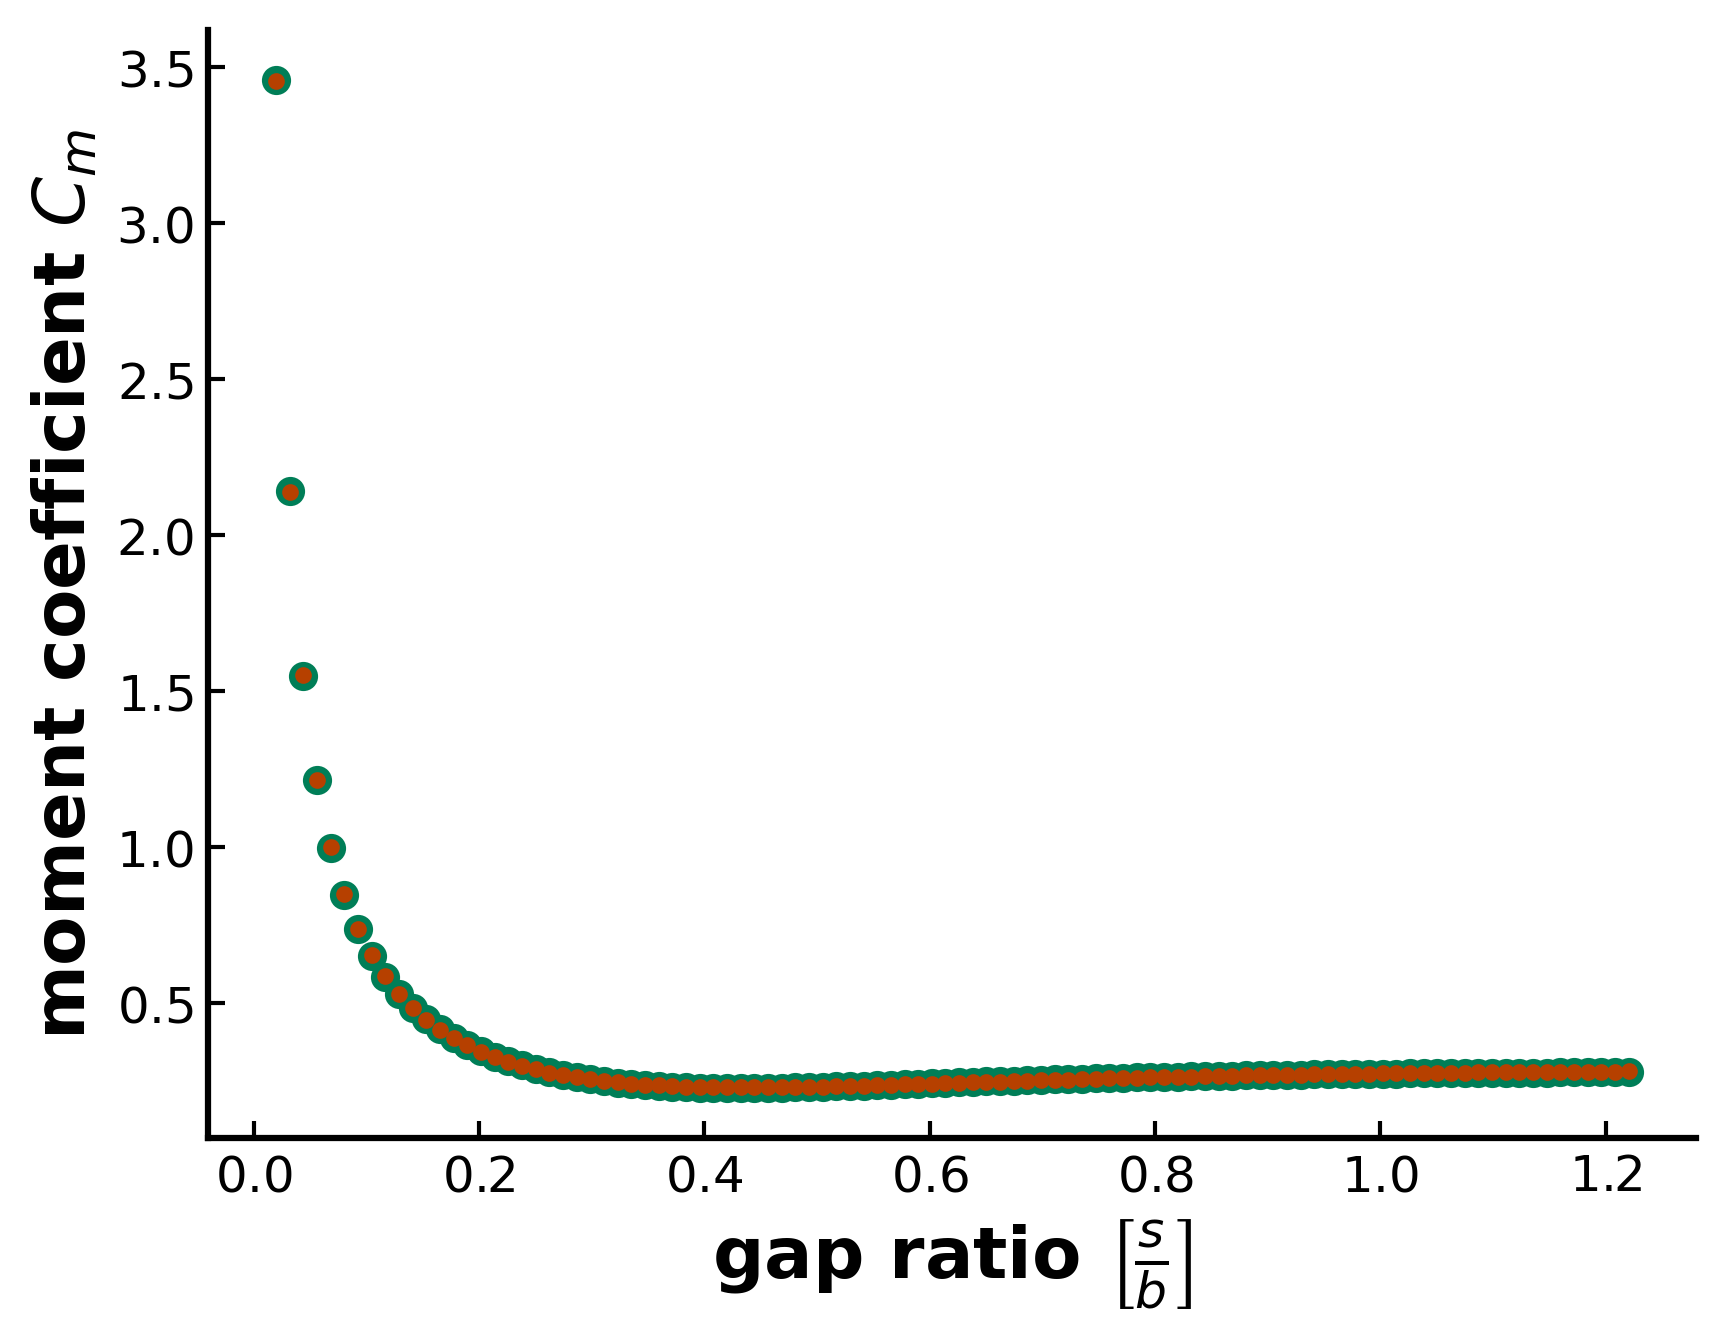

In [122]:
cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )
s_sound, M_phi, fit, popt = cylinder.disk_moment_fit(50e-6, 0.0031)

c_0 = popt[0]
c_1 = popt[1]
c_2 = popt[2]
c_3 = popt[3]
print(f"c_0: {c_0:.3f}")
print(f"c_1: {c_1:.3f}")
print(f"c_2: {c_2:.3f}")
print(f"c_3: {c_3:.3f}")

plt.plot(s_sound/cylinder.b, M_phi, linestyle = '', marker = 'o')
plt.plot(s_sound/cylinder.b, fit, linestyle = '', marker = '.')

plt.ylabel(r"moment coefficient $C_m$", weight = 'heavy', fontsize = "xx-large")
plt.xlabel(r"gap ratio $\left[\frac{s}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.show()

# **Normalized Dissipation v. Normalized Gap Distance**

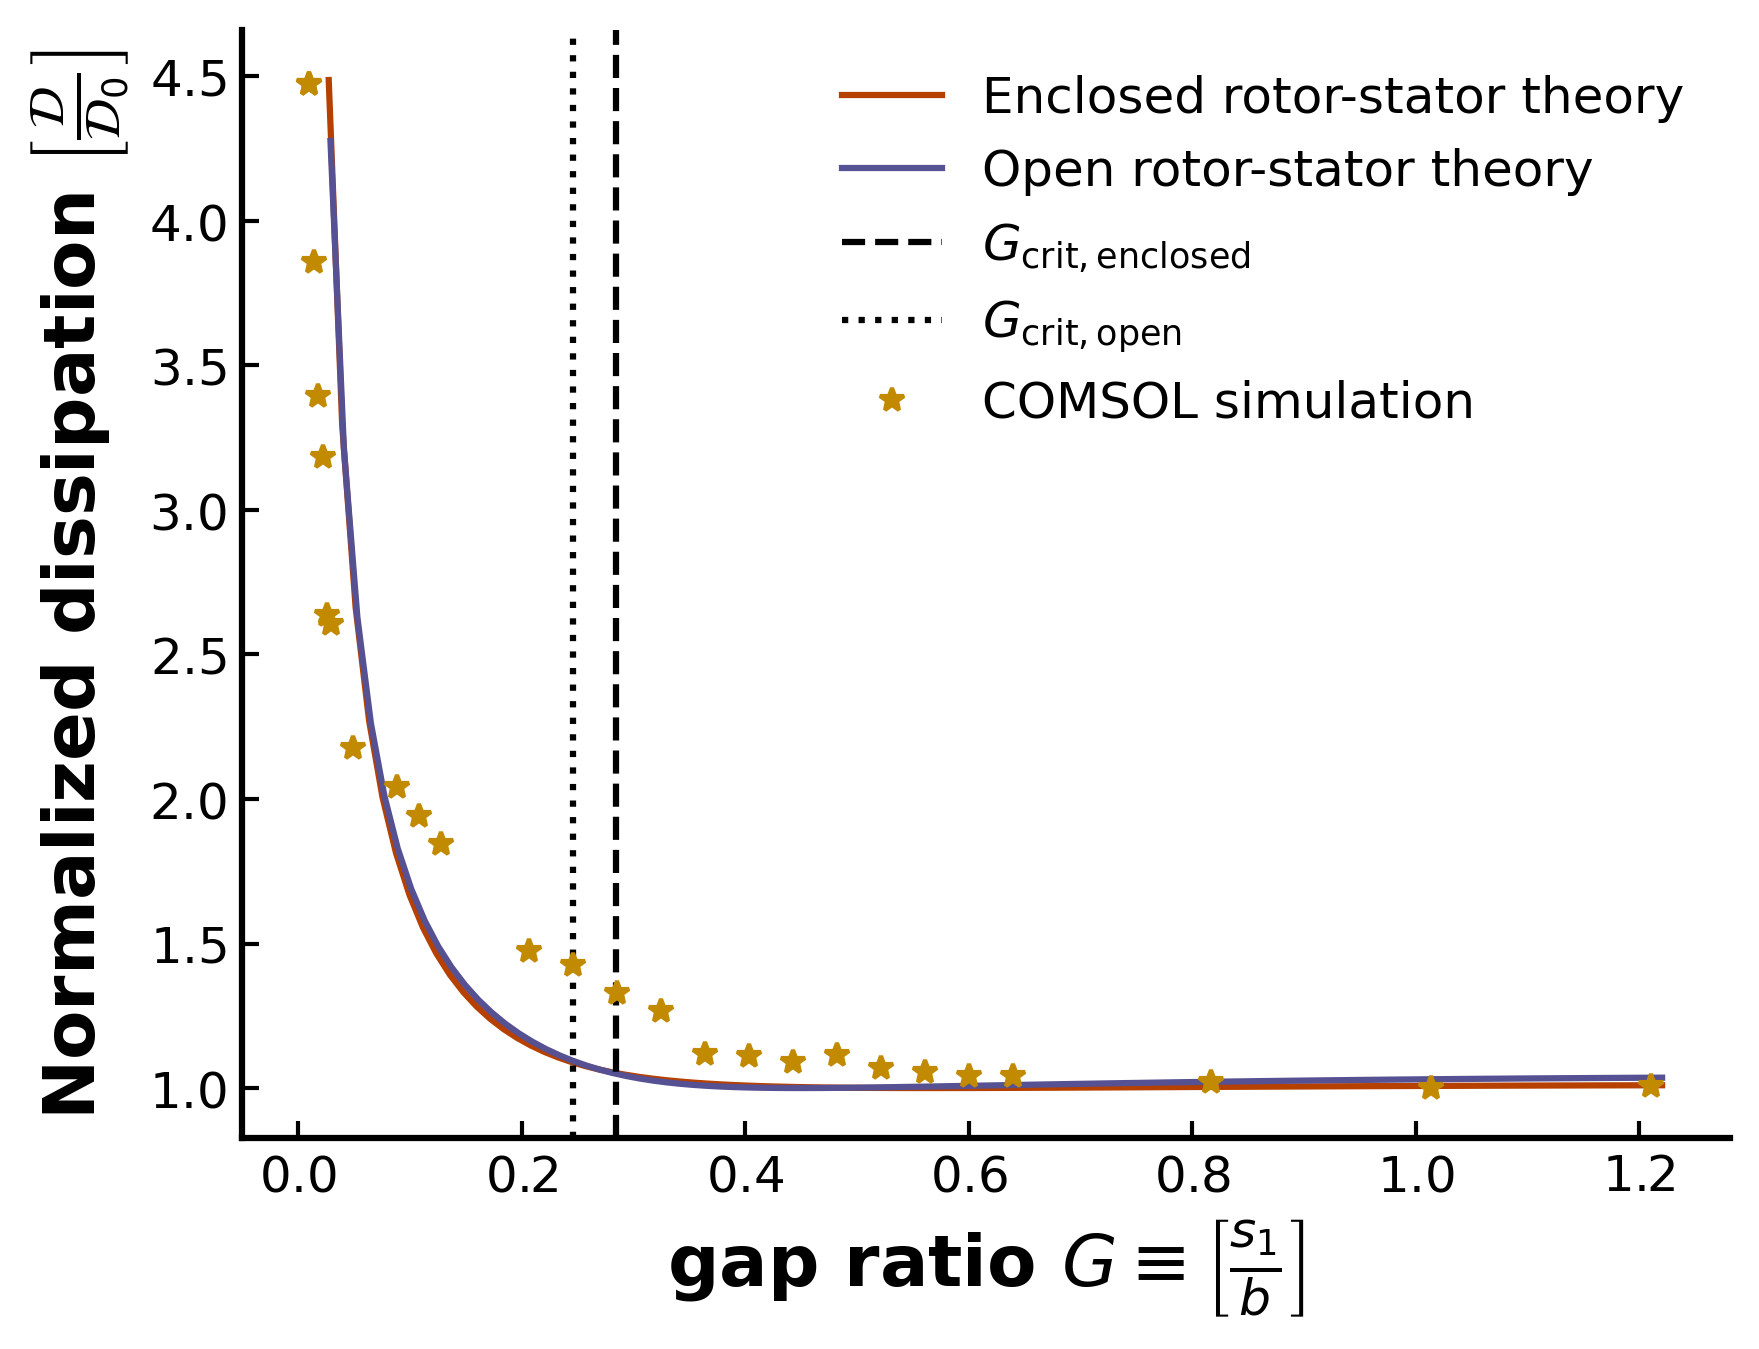

In [32]:
cylinder = Cylinder( 
            b = 0.00254,  # radius in meters
            rho = 7500, # cylinder density in kg/m^3
            Omega = 1000, # angular velocity in rpm 
            rho_f = 1.226, # density of the fluid in kg/m^3
            mu = 1.795e-5, # viscosity of the fluid in pascal seconds
            elle = 0.0105, # total gap distance in meters
            L = 0.003175 # length of the cylinder in meters
        )

gap_exp = np.asarray([0.00027, 0.00075, 0.00253]) #in meters
tau_exp = np.asarray([85, 100, 110]) #in seconds
dissipation_exp = cylinder.I *cylinder.Omega**2/(tau_exp*2*np.pi*cylinder.b*(cylinder.L + cylinder.b))

#Enclosed Rotor-Stator Fit
s_array_ers, dissipation_ers, G_crit_ers = cylinder.enclosed_rotor_stator(
    start = 69e-6, #in meters
    stop = 0.0031 # in meters
)

#Open Rotor-Stator Fit
s_array_ors, dissipation_ors , G_crit_ors = cylinder.open_rotor_stator(
    start = 73e-6, #in meters
    stop = 0.0031 # in meters
)

#COMSOL Simulation
gap_COMSOL = 2.075  + np.asarray([-2.05, -1.95, -1.85, -1.75, -1.55, -1.45, -1.35, -1.25, -1.15, -1.05, -0.9499999999999997, -0.8499999999999996, -0.7499999999999998,
                                    -0.6499999999999997, -0.5499999999999998, -0.4499999999999997, -2.05, -2.04, -2.03, -2.02, -2.01, -2, -1.8, 1, 0.5, 0]) # in mm
gap_COMSOL = gap_COMSOL/1000 #convert from mm to meters
dissipation_COMSOL = np.asarray([7.276218039755276e-08, 3.54147777132402e-08, 3.319989813145014e-08, 2.999256618224352e-08, 2.397974446357202e-08, 
                                    2.315700597492343e-08, 2.161300607312653e-08, 2.059531916586093e-08, 1.818476156508958e-08, 1.805479547545832e-08,
                                    1.770094325751496e-08, 1.810964892360439e-08, 1.738181837805184e-08, 1.713697045790447e-08, 1.696140911262177e-08,
                                    1.69594542751747e-08, 7.276218039755276e-08, 6.27325979686784e-08, 5.517541944117902e-08, 5.178201911733897e-08, 
                                    4.28650162841852e-08, 4.237478948935986e-08, 3.154069141653727e-08, 1.639943102219439e-08, 1.625977604031675e-08, 1.660765723313549e-08]) #in Watts/m^2

'''
Plotting
'''

# Enclosed Rotor-Stator
plt.plot(s_array_ers/cylinder.b, dissipation_ers/np.min(dissipation_ers), label = 'Enclosed rotor-stator theory', c = 'C1')

# Open Rotor-Stator
plt.plot(s_array_ors/cylinder.b, dissipation_ors/np.min(dissipation_ors), label = 'Open rotor-stator theory', c = 'C2')

# axvlines
plt.axvline(x = G_crit_ers, c = 'black', linestyle = '--', label = r'$G_\mathrm{crit, enclosed}$')
plt.axvline(x = G_crit_ors, c = 'black', linestyle = ':', label = r'$G_\mathrm{crit, open}$')

# COMSOL
plt.plot(gap_COMSOL/cylinder.b, dissipation_COMSOL/np.min(dissipation_COMSOL), linestyle = '', marker = '*', label = 'COMSOL simulation', c = 'C5')

# Experiment
#plt.plot(gap_exp/cylinder.b, dissipation_exp/np.min(dissipation_exp), linestyle = '', marker = 'o', c = 'C4', label = 'Experiment (assuming\nlinear damping)')


# Labels
plt.xlabel(r"gap ratio $G \equiv \left[\frac{s_1}{b} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.ylabel(r"Normalized dissipation $\left[\frac{\mathcal{D}}{\mathcal{D}_0} \right]$", weight = 'heavy', fontsize = "xx-large")
plt.legend(prop={'size': 12})
plt.show()

---